## 任务 1：大数定律实验

In [ ]:
import numpy as np

rng = np.random.default_rng(44)

def roller(N):
    rolls = rng.integers(1, 7, size=N)
    freq = np.bincount(rolls, minlength=7)[1:] / N
    dev = np.max(np.abs(freq - 1/6))
    return dev

print(10,roller(10))
print(100,roller(100))
print(10000,roller(10000))
print(1000000,roller(1000000))

## 任务 2：dice 的期望

In [ ]:
import numpy as np

rng = np.random.default_rng(44)

rolls = rng.integers(1, 7, size=1000000)
print(rolls.mean())

## 任务 1：离散→连续的桥

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

rng  = np.random.default_rng(42)

ks = np.arange(11)

bin = rng.binomial(n=10, p=0.3, size=100000)
list_ = np.unique(bin)
pred = np.bincount(bin, minlength=11)
plt.xlabel("number exist")
plt.ylabel("pred")
print(bin,"\n",list_,"\n",pred)

def PMF(n, p):
    #P(X=k)=C(N,k)·0.3^k·0.7^(10-k)
    pmf = np.array([math.comb(n, int(k)) for k in ks]) * p**ks * (1-p)**(n-ks)
    return pmf

print(PMF(10, 0.3))
print(PMF(10, 0.3) - pred/100000)

def poisson_PMF(k, lam):
    pmf = lam**k / math.factorial(k) * math.e**(-lam)
    return pmf

#对比
poisson_like = PMF(100, 0.3)
poisson = poisson_PMF(100, 3)

plt.bar(ks, pred/100000, label='sample')
plt.plot(ks, PMF(10,0.3), 'ro-', label='binomial PMF')
plt.legend(); plt.show()

## 任务 2：正态分布 + CLT 初体验

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

# 设置随机数生成器（可自行修改种子）
rng = np.random.default_rng(seed=42)

# ===== 任务2a：正态密度 =====
samples = rng.standard_normal(100000)
x = np.linspace(-4, 4, 400)                     # ← 横轴范围：±4σ
theory = np.exp(-x**2/2) / np.sqrt(2 * np.pi)   # ← 完整常数 √(2π)

plt.hist(samples, bins=100, density=True, label='sample')   # ← bins=100, density=True
plt.plot(x, theory, 'r-', lw=2, label='N(0,1)')
plt.legend()
plt.show()

# 自检1：面积
counts, edges = np.histogram(samples, bins=100, density=True)  # ← bins, density
print('面积 =', np.sum(counts * np.diff(edges)))                # ← 条宽×密度求和，应≈1

# ===== 任务2b：12 均匀之和 → 正态 =====
U = rng.uniform(0, 1, (100000, 12))          # ← 100000 行，12 列
s12 = U.sum(axis=1)                          # ← 对 axis=1 求和

plt.hist(s12, bins=100, density=True)
x2 = np.linspace(2, 10, 400)                # ← 覆盖 μ±4σ，μ=6, σ=1
print('实验均值 =', np.mean(s12), ' 理论 =', 6)          # ← 理论均值 12×0.5=6
print('实验方差 =', np.var(s12), ' 理论 =', 1)          # ← 理论方差 12×(1/12)=1

# 对照 N(6, 1) 密度
theory2 = np.exp(-(x2-6)**2/(2*1)) / np.sqrt(2*np.pi*1)   # ← μ=6, σ²=1
plt.plot(x2, theory2, 'r-', lw=2)
plt.show()

# ===== 任务2c：验证 1/√n =====
m12 = s12 / 12                              # ← 12个均匀的平均
print('实验 std(m12) =', np.std(m12), '理论 1/√12/√12 =', 1/np.sqrt(12)/np.sqrt(12))

## 任务 1：CLT 的实验完整版

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

rng = np.random.default_rng(seed=42)
n_pool = 30
miu = 1
sig2 = 1

def normlize(sn, n, miu, sig2):
    zn = (sn - n*miu) / math.sqrt(n*sig2)
    return zn

X = rng.exponential(1.0, (100000, n_pool))
fig, axes = plt.subplots(2, 2, figsize=(10,8))
for k,n in enumerate([1, 2, 5, 30]):
    sn = X[:, :n].sum(axis=1)
    zn = normlize(sn, n, miu, sig2)
    ax = axes[k//2][k%2]
    ax.hist(zn, bins=100, density=True)
    xs = np.linspace(-4, 4, 200)
    ax.plot(xs, np.exp(-xs**2/2)/np.sqrt(2*np.pi), 'r-')
    ax.set_title(f'n={n}')
plt.tight_layout(); plt.show()

## 任务 2：协方差——第一次两个随机变量

cov 残差 0.00570, corr 残差 0.000185


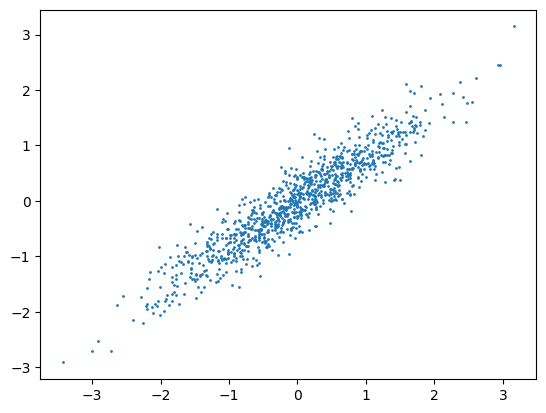

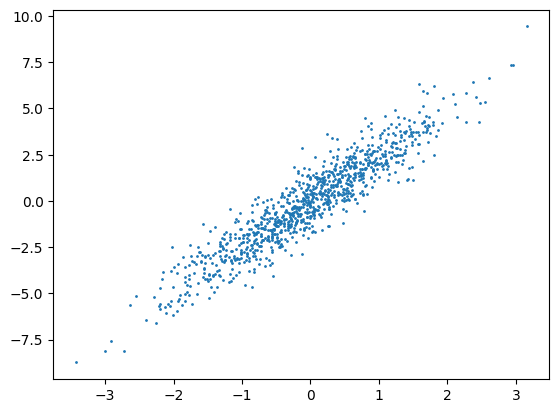

Text(0.5, 1.0, 'corr=0.000 独立')

/mnt/d/study-space/Ai/.venv/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAPH-76F8}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/mnt/d/study-space/Ai/.venv/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 20851 (\N{CJK UNIFIED IDEOGRAPH-5173}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/mnt/d/study-space/Ai/.venv/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 29420 (\N{CJK UNIFIED IDEOGRAPH-72EC}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/mnt/d/study-space/Ai/.venv/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 31435 (\N{CJK UNIFIED IDEOGRAPH-7ACB}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)


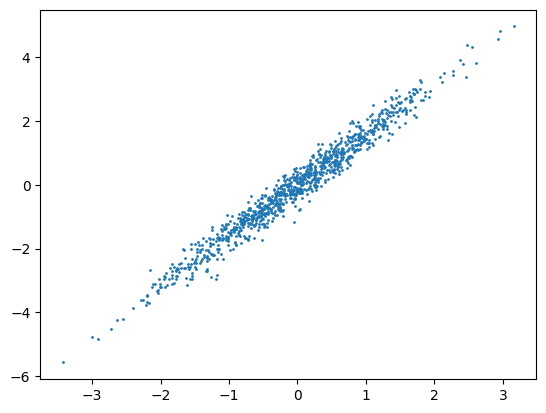

/mnt/d/study-space/Ai/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAPH-76F8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/mnt/d/study-space/Ai/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20851 (\N{CJK UNIFIED IDEOGRAPH-5173}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/mnt/d/study-space/Ai/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29420 (\N{CJK UNIFIED IDEOGRAPH-72EC}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/mnt/d/study-space/Ai/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 31435 (\N{CJK UNIFIED IDEOGRAPH-7ACB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


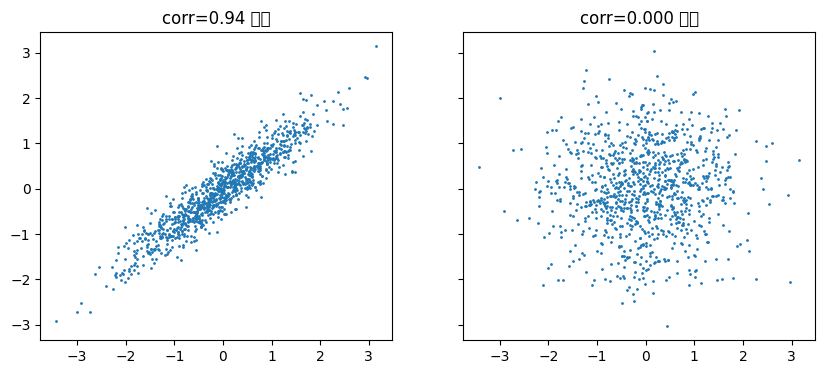

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import math

rng = np.random.default_rng(42)

x = rng.standard_normal(100000)
y = 0.8*x + 0.3*rng.standard_normal(100000)
y_ = 3*y
y__ = 0.8*2*x + 0.3*rng.standard_normal(100000)

cov_xy = np.cov(x, y)[0,1]
corr_xy = np.corrcoef(x, y)[0,1]
print(f'cov 残差 {abs(cov_xy-0.8):.5f}, corr 残差 {abs(corr_xy-0.936329):.6f}')

plt.scatter(x[::100], y[::100], s=1)
plt.show()
plt.scatter(x[::100], y_[::100], s=1)
plt.show()
plt.scatter(x[::100], y__[::100], s=1)

y2 = rng.standard_normal(100000)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10,4), sharex=True, sharey=True)
a1.scatter(x[::100], y[::100], s=1);   a1.set_title(f'corr=0.94 相关')
a2.scatter(x[::100], y2[::100], s=1);  a2.set_title(f'corr={np.corrcoef(x,y2)[0,1]:.3f} 独立')

-1.5857884429602167 0.2999478055510874


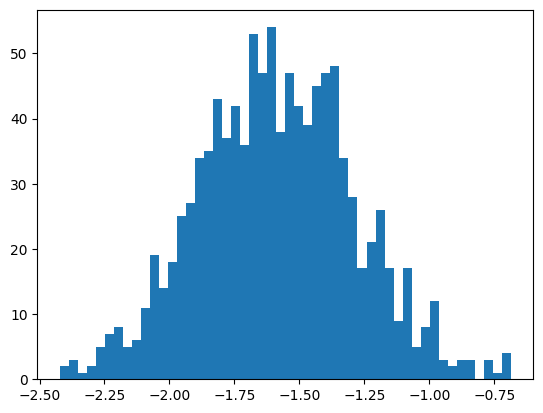

0.9923047457693702


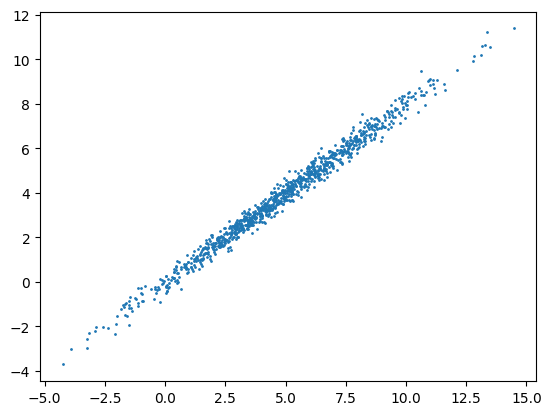

In [24]:
sel = np.abs(x - (-2.0)) < 0.1
plt.hist(y[sel], bins=50)
print(y[sel].mean(), y[sel].std())
plt.show()

x2 = 5 + 3*rng.standard_normal(100000)
plt.scatter(x2[::100], (0.8*x2+0.3*rng.standard_normal(100000))[::100], s=1)
print(np.corrcoef(x2, 0.8*x2+0.3*rng.standard_normal(100000))[0,1])